<a href="https://colab.research.google.com/github/PHAMVANTU467/DEEP-LEARNING/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cài thư viện cần thiết
!pip install -q scikeras

# =========================
# Import required libraries
# =========================

# Data processing
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Keras wrapper for scikit-learn
from scikeras.wrappers import KerasClassifier

# Model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   Label  Description
0      0  T-shirt/top
1      1      Trouser
2      2     Pullover
3      3        Dress
4      4         Coat
5      5       Sandal
6      6        Shirt
7      7      Sneaker
8      8          Bag
9      9   Ankle boot
Kích thước X_train: (60000, 28, 28)
Kích thước y_train: (60000,)
Kích thước X_test: (10000, 28, 28)
Kích thước y_test: (10000,)
Giá trị pixel nhỏ nhất: 0
Giá trị pixel lớn nhất: 255


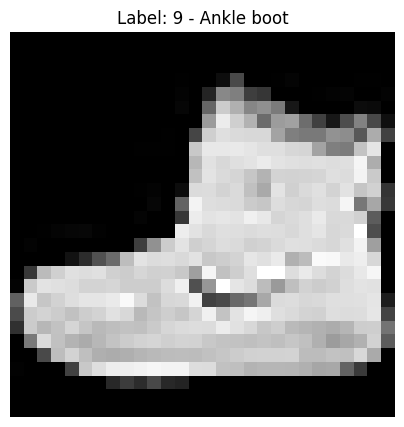

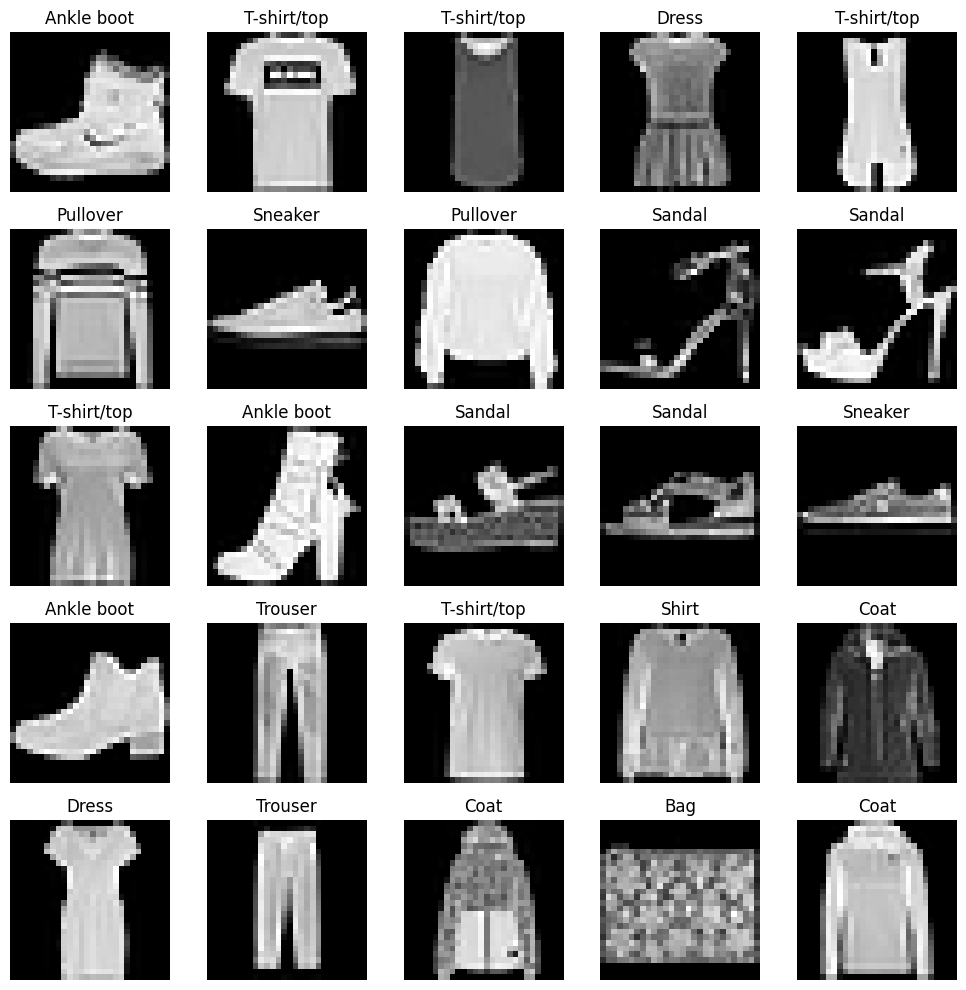

Sau tiền xử lý:
Kích thước X_train: (60000, 28, 28, 1)
Kích thước X_test: (10000, 28, 28, 1)
Giá trị pixel nhỏ nhất: 0.0
Giá trị pixel lớn nhất: 1.0


In [ ]:
# =========================
# 3.2. Đọc tập dữ liệu Fashion MNIST
# =========================

# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist


# =========================
# Đọc dữ liệu Fashion MNIST
# =========================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


# =========================
# Khai báo tên các lớp nhãn
# =========================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


# =========================
# Hiển thị bảng nhãn
# =========================

label_table = pd.DataFrame({
    "Label": list(range(10)),
    "Description": class_names
})

print(label_table)


# =========================
# Kiểm tra kích thước dữ liệu
# =========================

print("Kích thước X_train:", X_train.shape)
print("Kích thước y_train:", y_train.shape)
print("Kích thước X_test:", X_test.shape)
print("Kích thước y_test:", y_test.shape)

print("Giá trị pixel nhỏ nhất:", X_train.min())
print("Giá trị pixel lớn nhất:", X_train.max())


# =========================
# Hiển thị một ảnh mẫu
# =========================

plt.figure(figsize=(5, 5))
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]} - {class_names[y_train[0]]}")
plt.axis("off")
plt.show()


# =========================
# Hiển thị nhiều ảnh mẫu
# =========================

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


# =========================
# Tiền xử lý dữ liệu
# =========================

# Chuẩn hóa giá trị pixel từ [0, 255] về [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape dữ liệu để phù hợp với CNN
# Từ shape: (60000, 28, 28)
# Thành shape: (60000, 28, 28, 1)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)


# =========================
# Kiểm tra lại dữ liệu sau tiền xử lý
# =========================

print("Sau tiền xử lý:")
print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test:", X_test.shape)
print("Giá trị pixel nhỏ nhất:", X_train.min())
print("Giá trị pixel lớn nhất:", X_train.max())

In [ ]:
#reshape data from 3-D to 2-D array
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

#feature scaling
minmax = MinMaxScaler()

X_train = minmax. fit_transform(X_train)
X_test = minmax. transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


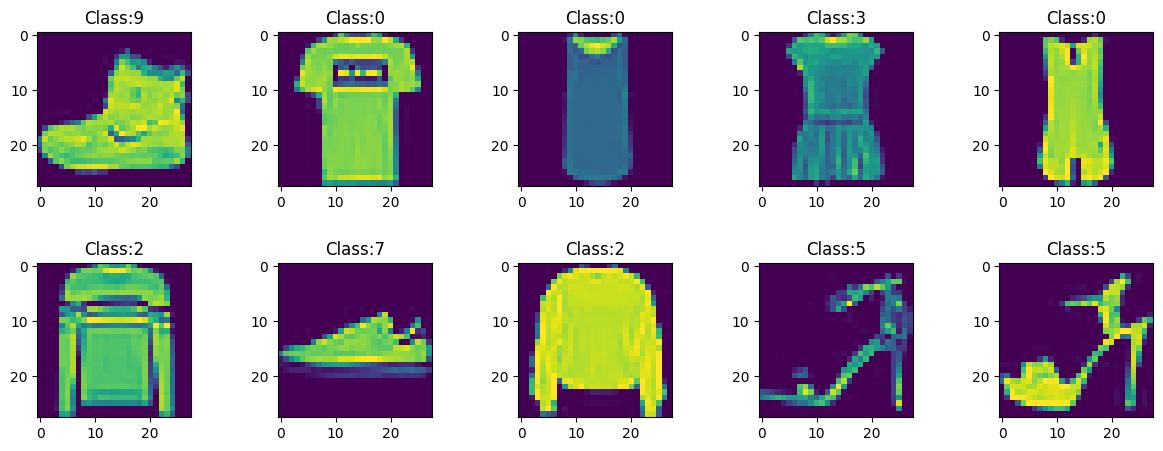

In [ ]:
#Data visualization
fig, axes = plt. subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
# =========================
# Import thư viện
# =========================

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# =========================
# Đọc dữ liệu Fashion MNIST
# =========================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


# =========================
# Khai báo tên lớp
# =========================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


# =========================
# Tiền xử lý dữ liệu
# =========================

# Chuyển kiểu dữ liệu sang float32
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Chuẩn hóa pixel từ [0, 255] về [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Làm phẳng ảnh 28x28 thành vector 784 chiều
X_train = X_train.reshape(X_train.shape[0], 28 * 28)
X_test = X_test.reshape(X_test.shape[0], 28 * 28)


# =========================
# Kiểm tra kích thước dữ liệu
# =========================

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


# =========================
# Initial ANN model
# =========================

fashion_model = Sequential()


# =========================
# Add first hidden layer
# =========================

fashion_model.add(Dense(
    units=256,
    input_dim=X_train.shape[1],
    kernel_initializer="uniform",
    activation="relu"
))


# =========================
# Add dropout layer
# =========================

fashion_model.add(Dropout(0.3))


# =========================
# Add second hidden layer
# =========================

fashion_model.add(Dense(
    units=128,
    kernel_initializer="uniform",
    activation="relu"
))


# =========================
# Add output layer
# =========================

fashion_model.add(Dense(
    units=10,
    kernel_initializer="uniform",
    activation="softmax"
))


# =========================
# Compile neural network
# =========================

fashion_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# Model summary
# =========================

fashion_model.summary()


# =========================
# Train model
# =========================

history = fashion_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


# =========================
# Evaluate model
# =========================

test_loss, test_accuracy = fashion_model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


# =========================
# Predict sample
# =========================

index = 0

prediction = fashion_model.predict(X_test[index:index + 1])
predicted_label = np.argmax(prediction)

print("Nhãn dự đoán:", predicted_label, "-", class_names[predicted_label])
print("Nhãn thật:", y_test[index], "-", class_names[y_test[index]])

X_train shape: (60000, 784)
y_train shape: (60000,)
X_test shape: (10000, 784)
y_test shape: (10000,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7838 - loss: 0.6006 - val_accuracy: 0.8383 - val_loss: 0.4359
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8470 - loss: 0.4196 - val_accuracy: 0.8511 - val_loss: 0.4038
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8624 - loss: 0.3754 - val_accuracy: 0.8676 - val_loss: 0.3622
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8685 - loss: 0.3563 - val_accuracy: 0.8777 - val_loss: 0.3501
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8745 - loss: 0.3394 - val_accuracy: 0.8781 - val_loss: 0.3418
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8774 - loss: 0.3274 - val_accuracy: 0.8769 - val_loss: 0.3360
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8819 - loss: 0.3143 - val_accuracy: 0.8838 - val_loss: 0.3173
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8863 - loss: 0.3049 - val_accuracy: 0.

In [ ]:
model_fit = fashion_model.fit(X_train, y_train, batch_size=64, epochs=10, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8942 - loss: 0.2821 - val_accuracy: 0.8834 - val_loss: 0.3135
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8956 - loss: 0.2773 - val_accuracy: 0.8868 - val_loss: 0.3182
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8979 - loss: 0.2700 - val_accuracy: 0.8898 - val_loss: 0.3053
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9016 - loss: 0.2612 - val_accuracy: 0.8893 - val_loss: 0.3128
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9029 - loss: 0.2570 - val_accuracy: 0.8871 - val_loss: 0.3089
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9037 - loss: 0.2541 - val_accuracy: 0.8932 - val_loss: 0.3105
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9051 - loss: 0.2513 - val_accuracy: 0.8905 - val_loss: 0.3079
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9082 - loss: 0.2457 - val_accuracy: 0.

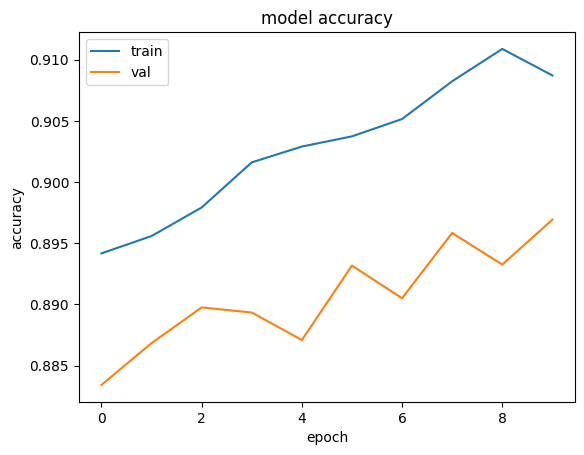

In [ ]:
plt.plot(model_fit.history['accuracy' ])
plt.plot(model_fit.history['val_accuracy'])
plt. title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt. legend(['train', 'val'], loc='upper left')
plt.show()

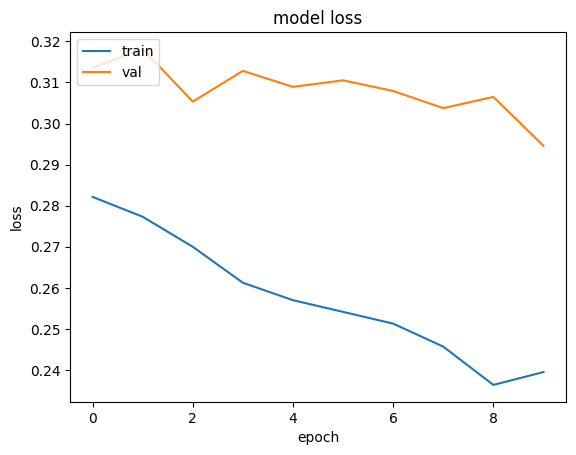

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss' ])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test) [10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [ ]:
# =========================
# Import thư viện
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist


# =========================
# Đọc dữ liệu Fashion MNIST
# =========================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


# =========================
# Kiểm tra dữ liệu gốc
# =========================

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
# =========================
# Chuyển dữ liệu ảnh thành dạng bảng giống CSV
# =========================

X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

pixel_columns = [f"pixel{i}" for i in range(1, 785)]

mnist_train = pd.DataFrame(X_train_flat, columns=pixel_columns)
mnist_test = pd.DataFrame(X_test_flat, columns=pixel_columns)

mnist_train.insert(0, "label", y_train)
mnist_test.insert(0, "label", y_test)


# =========================
# Kiểm tra DataFrame
# =========================

print(mnist_train.head())
print(mnist_train.shape)

print(mnist_test.head())
print(mnist_test.shape)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      9       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       1       0       0   
2      0       0       0       0       0       0       0       0       0   
3      3       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...       119       114       130        76         0         0   
2       0  ...         0         0         1         0         0         0   
3      33  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [ ]:
# =========================
# Import thư viện
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# =========================
# Đọc dữ liệu Fashion MNIST
# =========================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


# =========================
# Danh sách tên nhãn
# =========================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


# =========================
# Chuyển dữ liệu về dạng bảng giống CSV
# =========================

X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

pixel_columns = [f"pixel{i}" for i in range(1, 785)]

mnist_train = pd.DataFrame(X_train_flat, columns=pixel_columns)
mnist_test = pd.DataFrame(X_test_flat, columns=pixel_columns)

mnist_train.insert(0, "label", y_train)
mnist_test.insert(0, "label", y_test)


# =========================
# Kiểm tra dữ liệu
# =========================

print(mnist_train.head())
print("Train shape:", mnist_train.shape)
print("Test shape:", mnist_test.shape)


# =========================
# Tách X và y
# =========================

X_train = mnist_train.drop("label", axis=1).values
y_train = mnist_train["label"].values

X_test = mnist_test.drop("label", axis=1).values
y_test = mnist_test["label"].values


# =========================
# Chuẩn hóa dữ liệu
# =========================

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# =========================
# Xây dựng mô hình ANN
# =========================

fashion_model = Sequential()

fashion_model.add(Dense(
    units=256,
    input_dim=X_train.shape[1],
    kernel_initializer="uniform",
    activation="relu"
))

fashion_model.add(Dropout(0.3))

fashion_model.add(Dense(
    units=128,
    kernel_initializer="uniform",
    activation="relu"
))

fashion_model.add(Dropout(0.3))

fashion_model.add(Dense(
    units=10,
    kernel_initializer="uniform",
    activation="softmax"
))


# =========================
# Compile model
# =========================

fashion_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# Model summary
# =========================

fashion_model.summary()


# =========================
# Train model
# =========================

history = fashion_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


# =========================
# Evaluate model
# =========================

test_loss, test_accuracy = fashion_model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      9       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       1       0       0   
2      0       0       0       0       0       0       0       0       0   
3      3       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...       119       114       130        76         0         0   
2       0  ...         0         0         1         0         0         0   
3      33  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7680 - loss: 0.6349 - val_accuracy: 0.8449 - val_loss: 0.4228
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8431 - loss: 0.4368 - val_accuracy: 0.8521 - val_loss: 0.4074
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8557 - loss: 0.3944 - val_accuracy: 0.8676 - val_loss: 0.3595
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8644 - loss: 0.3718 - val_accuracy: 0.8761 - val_loss: 0.3451
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8698 - loss: 0.3563 - val_accuracy: 0.8763 - val_loss: 0.3454
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8764 - loss: 0.3403 - val_accuracy: 0.8780 - val_loss: 0.3355
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8785 - loss: 0.3311 - val_accuracy: 0.8776 - val_loss: 0.3280
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8814 - loss: 0.3194 - val_accuracy: 0.

In [ ]:
X_train = mnist_train.iloc[:,1:]
X_test = mnist_test. iloc[ :,1:]
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

(60000, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] )
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7896 - loss: 0.9409
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8281 - loss: 0.4985
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8370 - loss: 0.4792
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8416 - loss: 0.4710
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8450 - loss: 0.4575
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8479 - loss: 0.4515
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8500 - loss: 0.4444
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8513 - loss: 0.4378
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8526 - loss: 0.4358
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8539 - loss: 0.4359
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8551 - loss: 0.4281
Epoch 12/30
1875/1875 ━━━

In [ ]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])
print(np.argmax(model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving a4.jpg to a4.jpg


Shape ảnh đưa vào model: (1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
Kết quả xác suất: [[0.15423357 0.09948802 0.08186957 0.0625244  0.07702655 0.0043592
  0.07221225 0.01005711 0.4320125  0.00621683]]
Nhãn dự đoán: 8
Tên lớp dự đoán: Bag


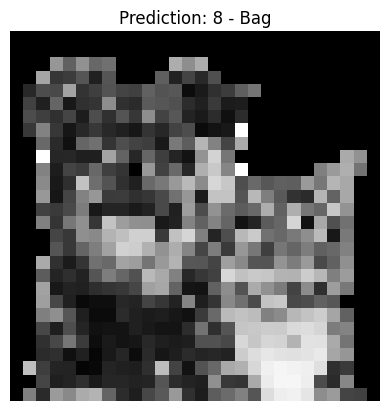

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Danh sách tên lớp của Fashion MNIST
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Đường dẫn ảnh sau khi upload lên Colab
img_path = "/content/a4.jpg"

# Kích thước ảnh Fashion MNIST
img_size = (28, 28)

# Load ảnh grayscale và resize về 28x28
img = tf.keras.preprocessing.image.load_img(
    img_path,
    color_mode="grayscale",
    target_size=img_size
)

# Chuyển ảnh thành array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# Đưa pixel về [0, 1]
img_array = img_array.astype("float32") / 255.0

# Vì model ANN nhận input dạng 784 chiều
img_array = img_array.reshape(1, 28 * 28)

print("Shape ảnh đưa vào model:", img_array.shape)

# Dự đoán
img_predict = fashion_model.predict(img_array)

print("Kết quả xác suất:", img_predict)

score = np.argmax(img_predict)

print("Nhãn dự đoán:", score)
print("Tên lớp dự đoán:", class_names[score])

# Hiển thị ảnh
plt.imshow(img_array.reshape(28, 28), cmap="gray")
plt.title(f"Prediction: {score} - {class_names[score]}")
plt.axis("off")
plt.show()

1. Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow
với các nhãn sau

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 30s 0us/step
X_train shape ban đầu: (50000, 32, 32, 3)
y_train shape ban đầu: (50000, 1)
X_test shape ban đầu: (10000, 32, 32, 3)
y_test shape ban đầu: (10000, 1)
Giá trị pixel nhỏ nhất: 0
Giá trị pixel lớn nhất: 255


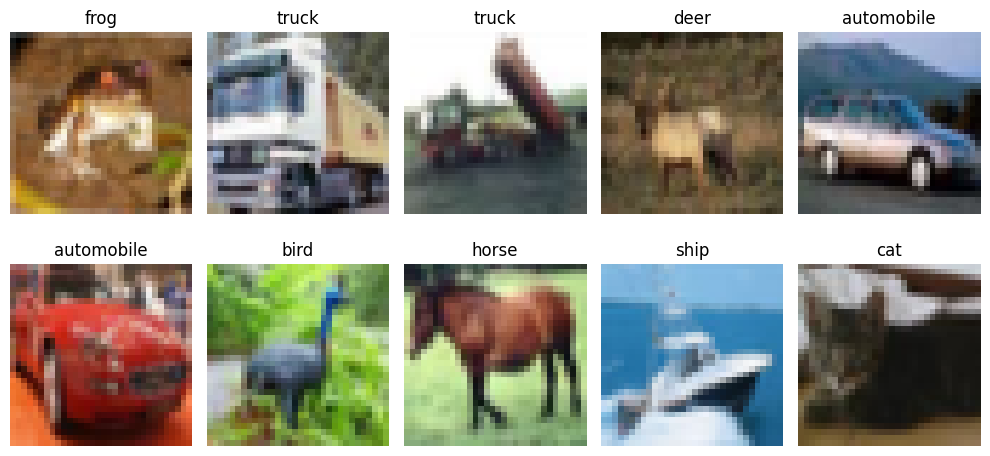

X_train shape sau xử lý: (50000, 3072)
y_train shape sau xử lý: (50000,)
X_test shape sau xử lý: (10000, 3072)
y_test shape sau xử lý: (10000,)
Giá trị pixel nhỏ nhất sau chuẩn hóa: 0.0
Giá trị pixel lớn nhất sau chuẩn hóa: 1.0


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 100ms/step - accuracy: 0.2292 - loss: 2.1079 - val_accuracy: 0.3360 - val_loss: 1.8728
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.2977 - loss: 1.9101 - val_accuracy: 0.3394 - val_loss: 1.8628
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.3136 - loss: 1.8725 - val_accuracy: 0.3577 - val_loss: 1.8044
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.3218 - loss: 1.8437 - val_accuracy: 0.3542 - val_loss: 1.8209
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.3304 - loss: 1.8195 - val_accuracy: 0.3711 - val_loss: 1.7510
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.3431 - loss: 1.7922 - val_accuracy: 0.3891 - val_loss: 1.7444
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.3471 - loss: 1.7840 - val_accuracy: 0.3930 - val_loss: 1.7304
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 104ms/step - accuracy: 0.3545 - loss: 1.7674

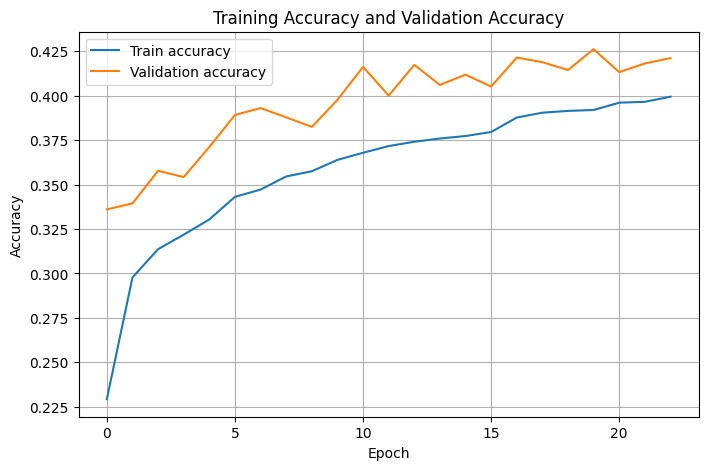

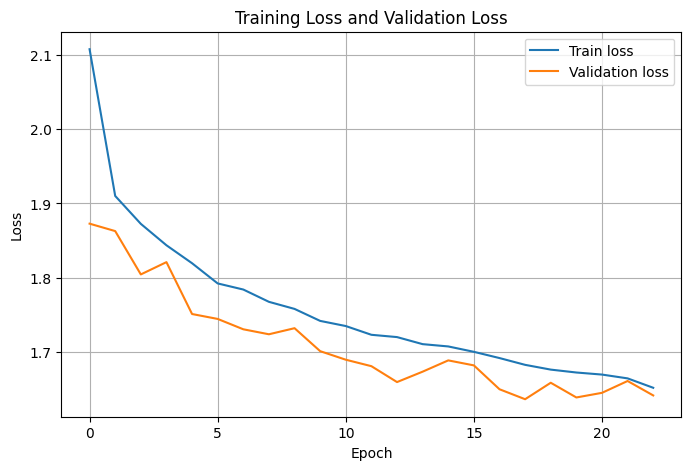

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Classification report:
              precision    recall  f1-score   support

    airplane       0.61      0.30      0.40      1000
  automobile       0.56      0.56      0.56      1000
        bird       0.29      0.11      0.16      1000
         cat       0.25      0.15      0.19      1000
        deer       0.32      0.51      0.39      1000
         dog       0.42      0.33      0.37      1000
        frog       0.36      0.59      0.45      1000
       horse       0.46      0.52      0.48      1000
        ship       0.48      0.67      0.56      1000
       truck       0.51      0.51      0.51      1000

    accuracy                           0.42     10000
   macro avg       0.43      0.42      0.41     10000
weighted avg       0.43      0.42      0.41     10000

Confusion matrix:
[[297  45  54  49  58   8  36  96 304  53]
 [ 17 557  12  37  18  12  35  31 107 174]
 [ 60  27 114  67 346  60 169  93  46  18]
 [  6  25  46 154 111 213 282

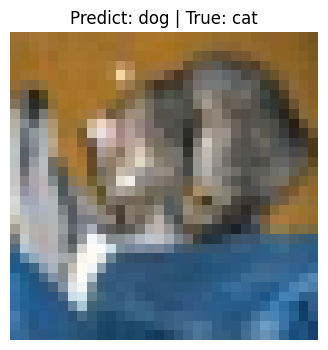

In [ ]:
# =========================
# 1. Import thư viện
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix


# =========================
# 2. Đọc dataset CIFAR-10
# =========================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()


# =========================
# 3. Khai báo tên các lớp nhãn
# =========================

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


# =========================
# 4. Kiểm tra dữ liệu ban đầu
# =========================

print("X_train shape ban đầu:", X_train.shape)
print("y_train shape ban đầu:", y_train.shape)
print("X_test shape ban đầu:", X_test.shape)
print("y_test shape ban đầu:", y_test.shape)

print("Giá trị pixel nhỏ nhất:", X_train.min())
print("Giá trị pixel lớn nhất:", X_train.max())


# =========================
# 5. Hiển thị một số ảnh mẫu
# =========================

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    label = int(y_train[i][0])
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()


# =========================
# 6. Tiền xử lý dữ liệu
# =========================

# Chuyển nhãn từ shape (50000, 1) thành (50000,)
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

# Chuẩn hóa pixel từ [0, 255] về [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Làm phẳng ảnh 32x32x3 thành vector 3072 chiều
X_train = X_train.reshape(X_train.shape[0], 32 * 32 * 3)
X_test = X_test.reshape(X_test.shape[0], 32 * 32 * 3)


# =========================
# 7. Kiểm tra dữ liệu sau tiền xử lý
# =========================

print("X_train shape sau xử lý:", X_train.shape)
print("y_train shape sau xử lý:", y_train.shape)
print("X_test shape sau xử lý:", X_test.shape)
print("y_test shape sau xử lý:", y_test.shape)

print("Giá trị pixel nhỏ nhất sau chuẩn hóa:", X_train.min())
print("Giá trị pixel lớn nhất sau chuẩn hóa:", X_train.max())


# =========================
# 8. Xây dựng mô hình ANN
# =========================

ann_model = Sequential()

ann_model.add(Input(shape=(3072,)))

ann_model.add(Dense(
    units=1024,
    activation="relu",
    kernel_initializer="he_uniform"
))

ann_model.add(Dropout(0.3))

ann_model.add(Dense(
    units=512,
    activation="relu",
    kernel_initializer="he_uniform"
))

ann_model.add(Dropout(0.3))

ann_model.add(Dense(
    units=256,
    activation="relu",
    kernel_initializer="he_uniform"
))

ann_model.add(Dropout(0.3))

ann_model.add(Dense(
    units=10,
    activation="softmax"
))


# =========================
# 9. Compile mô hình
# =========================

ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# 10. Hiển thị kiến trúc mô hình
# =========================

ann_model.summary()


# =========================
# 11. Huấn luyện mô hình
# =========================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


# =========================
# 12. Đánh giá mô hình trên tập test
# =========================

test_loss, test_accuracy = ann_model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


# =========================
# 13. Vẽ biểu đồ accuracy và loss
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 14. Dự đoán trên tập test
# =========================

y_pred_prob = ann_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)


# =========================
# 15. Báo cáo phân loại
# =========================

print("Classification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


# =========================
# 16. Ma trận nhầm lẫn
# =========================

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)


# =========================
# 17. Dự đoán một ảnh bất kỳ trong tập test
# =========================

index = 0

sample = X_test[index].reshape(1, 3072)

prediction = ann_model.predict(sample)
predicted_label = np.argmax(prediction)

print("Nhãn dự đoán:", predicted_label, "-", class_names[predicted_label])
print("Nhãn thật:", y_test[index], "-", class_names[y_test[index]])

plt.figure(figsize=(4, 4))
plt.imshow(X_test[index].reshape(32, 32, 3))
plt.title(
    "Predict: " + class_names[predicted_label] +
    " | True: " + class_names[y_test[index]]
)
plt.axis("off")
plt.show()